In [1]:
import numpy as np
import pandas as pd
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

N = 20000                
dt_seconds = 60          
start = datetime(2024,1,1)

time = [start + timedelta(seconds=i*dt_seconds) for i in range(N)]
base_pressure = 100 + 0.1 * np.sin(np.linspace(0, 50, N))    
base_flow = 500 + 2.0 * np.sin(np.linspace(0, 20, N))       
base_vibration = 1.0 + 0.01 * np.sin(np.linspace(0, 30, N)) 

noise_p = np.random.normal(0, 0.3, size=N)
noise_f = np.random.normal(0, 1.0, size=N)
noise_v = np.random.normal(0, 0.02, size=N)

pressure = base_pressure + noise_p
flow = base_flow + noise_f
vibration = base_vibration + noise_v
labels = np.zeros(N, dtype=int)

def inject_gradual_ramp(arr, start_idx, length, magnitude):
    end = min(len(arr), start_idx + length)
    ramp = np.linspace(0, magnitude, end - start_idx)
    arr[start_idx:end] += ramp

def inject_spike(arr, idx, magnitude, decay=0):
    if idx < len(arr):
        arr[idx] += magnitude
        for d in range(1, decay+1):
            if idx+d < len(arr):
                arr[idx+d] += magnitude * (0.5 ** d)

num_ramps = 60
num_spikes = 120

for _ in range(num_ramps):
    s = random.randint(100, N-200)
    length = random.randint(10, 120)        
    mag = random.uniform(0.2, 2.0)         
    inject_gradual_ramp(vibration, s, length, mag)
    labels[s:s+length] = 1

for _ in range(num_spikes):
    s = random.randint(50, N-50)
    which = random.choice(['pressure', 'flow'])
    mag = random.uniform(3.0, 15.0)       
    decay = random.choice([0, 1, 3])       
    if which == 'pressure':
        inject_spike(pressure, s, mag, decay=decay)
    else:
        inject_spike(flow, s, mag, decay=decay)
    labels[s:s+1+decay] = 1

for _ in range(80):
    s = random.randint(0, N-10)
    vibration[s:s+3] += np.random.normal(0, 0.05, size=3)  
df = pd.DataFrame({
    'timestamp': time,
    'pressure_psi': pressure,
    'flow_rate_bbl_day': flow,
    'vibration_mm_s': vibration,
    'warning_class': labels
})

print("Total rows:", len(df))
print("Labels distribution:\n", df['warning_class'].value_counts())
df.to_csv("final_simulated_sensor_data.csv", index=False)
print("Saved final_simulated_sensor_data.csv")

Total rows: 20000
Labels distribution:
 warning_class
0    16257
1     3743
Name: count, dtype: int64
Saved final_simulated_sensor_data.csv


In [3]:
import pandas as pd
df = pd.read_csv("final_simulated_sensor_data.csv")
print(df.head())
print(df.info())
print(df['warning_class'].value_counts())

             timestamp  pressure_psi  flow_rate_bbl_day  vibration_mm_s  \
0  2024-01-01 00:00:00    100.149014         500.348286        0.990563   
1  2024-01-01 00:01:00     99.958771         500.285324        1.020269   
2  2024-01-01 00:02:00    100.194807         499.067480        0.996066   
3  2024-01-01 00:03:00    100.457659         500.585585        1.001856   
4  2024-01-01 00:04:00     99.930754         498.517918        1.014408   

   warning_class  
0              0  
1              0  
2              0  
3              0  
4              0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          20000 non-null  object 
 1   pressure_psi       20000 non-null  float64
 2   flow_rate_bbl_day  20000 non-null  float64
 3   vibration_mm_s     20000 non-null  float64
 4   warning_class      20000 non-null 

In [5]:
df['pressure_diff'] = df['pressure_psi'].diff()
df['flow_rate_pct_change'] = df['flow_rate_bbl_day'].pct_change()
df['vibration_diff'] = df['vibration_mm_s'].diff()
df = df.fillna(0)

In [11]:
import numpy as np
sequence_length = 10  
features = ['pressure_psi', 'flow_rate_bbl_day', 'vibration_mm_s', 'pressure_diff', 'flow_rate_pct_change', 'vibration_diff']

X = []
y = []
data = df[features].values
labels = df['warning_class'].values

for i in range(len(data) - sequence_length):
    X.append(data[i:i+sequence_length])
    y.append(labels[i+sequence_length])

X = np.array(X)
y = np.array(y)
print("Shape of X:", X.shape) 
print("Shape of y:", y.shape)

Shape of X: (19990, 10, 6)
Shape of y: (19990,)


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_reshaped = X.reshape(-1, X.shape[2])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X.shape)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization

model = Sequential([
    GRU(64, input_shape=(sequence_length, len(features)), return_sequences=False),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\pssra\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          13,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,193 (63.25 KB)

 Trainable params: 16,065 (62.75 KB)

 Non-trainable params: 128 (512.00 B)

In [17]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9033 - loss: 0.3007 - val_accuracy: 0.9670 - val_loss: 0.1295
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9661 - loss: 0.1389 - val_accuracy: 0.9702 - val_loss: 0.1125
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9695 - loss: 0.1308 - val_accuracy: 0.9712 - val_loss: 0.1171
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9679 - loss: 0.1341 - val_accuracy: 0.9710 - val_loss: 0.1110
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9686 - loss: 0.1309 - val_accuracy: 0.9525 - val_loss: 0.1691
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9672 - loss: 0.1344 - val_accuracy: 0.9730 - val_loss: 0.1120
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9678 - loss: 0.1300 - val_accuracy: 0.9742 - val_loss: 0.1076
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9691 - loss: 0.1221 - val_accurac

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3246
           1       0.98      0.87      0.92       752

    accuracy                           0.97      3998
   macro avg       0.97      0.93      0.95      3998
weighted avg       0.97      0.97      0.97      3998

[[3231   15]
 [  97  655]]


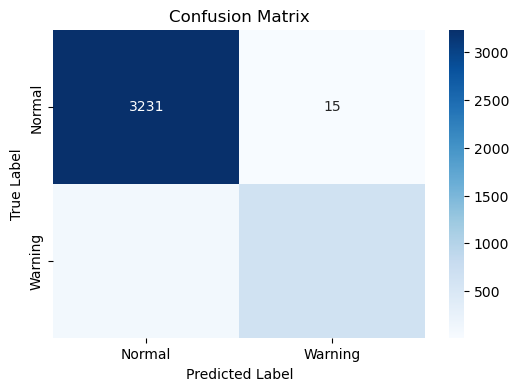

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Warning"], yticklabels=["Normal", "Warning"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


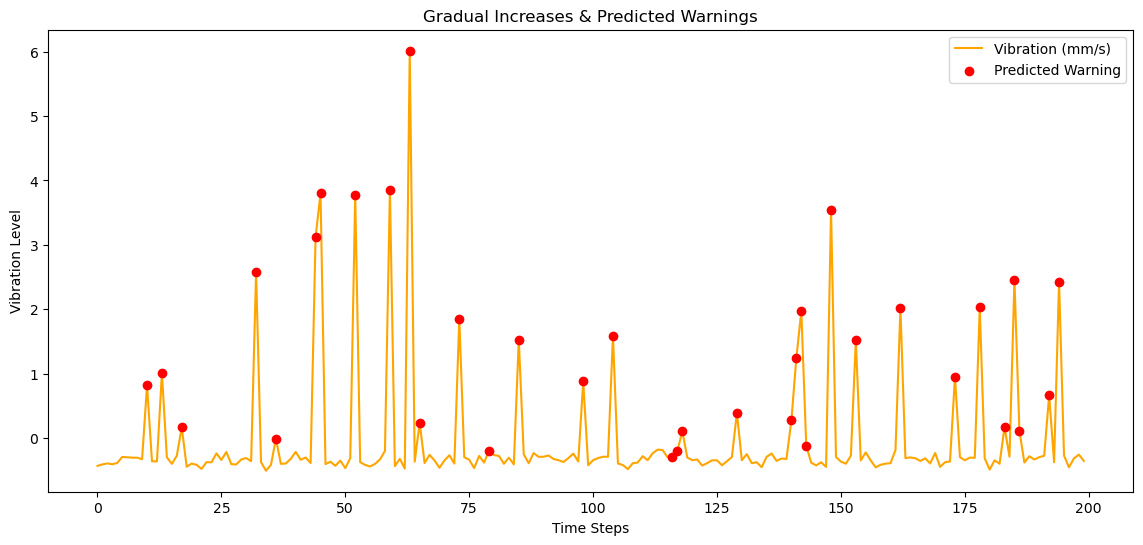

In [21]:
import matplotlib.pyplot as plt
import numpy as np

time_steps = np.arange(len(X_test))
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

segment = 200
plt.figure(figsize=(14,6))
plt.plot(time_steps[:segment], X_test[:segment, -1, 2], label="Vibration (mm/s)", color='orange')

warning_indices = np.where(y_pred_classes[:segment] == 1)[0]
plt.scatter(warning_indices, X_test[warning_indices, -1, 2], 
            color='red', label="Predicted Warning", zorder=5)

plt.xlabel("Time Steps")
plt.ylabel("Vibration Level")
plt.title("Gradual Increases & Predicted Warnings")
plt.legend()
plt.show()

In [25]:
import time
def alert_supervisor(vibration, pressure, flow, pred_prob):
    print(f"ALERT: Potential issue detected!")
    print(f"Vibration: {vibration:.2f} mm/s | Pressure: {pressure:.2f} psi | Flow: {flow:.2f} bbl/day")
    print(f"Risk Score: {pred_prob*100:.1f}%\n")

for i in range(50):
    input_data = X_test[i:i+1]
    pred_prob = model.predict(input_data)[0][0]
    pred_class = int(pred_prob > 0.5)

    if pred_class == 1:
        vibration = input_data[0, -1, 2]
        pressure = input_data[0, -1, 0]
        flow = input_data[0, -1, 1]
        alert_supervisor(vibration, pressure, flow, pred_prob)

    time.sleep(0.2)  

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
ALERT: Potential issue detected!
Vibration: 0.82 mm/s | Pressure: 0.63 psi | Flow: 0.96 bbl/day
Risk Score: 95.5%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
ALERT: Potential issue detected!
Vibration: 1.01 mm/s | Pressure: 0.28 psi | Flow: 1.64 bbl/day
Risk Score: 95.9%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
ALERT: Potential issue detected!
Vibration: 0.17 mm/s | Pressure: -0.38 psi | Flow: 0.